## Extract shape from NDVI

In [1]:
# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch
from PIL import Image
import cv2
import leafmap.leafmap as leafmap
from skimage.measure import label, regionprops
from IPython.display import display

# Create a custom colormap for NDVI visualization
ndvi_cmap = LinearSegmentedColormap.from_list(
    'ndvi',
    [(0.0, 'red'), (0.5, 'yellow'), (1.0, 'green')],
    N=256
)

Starting plant detection with shapes and centroids...
Loaded RGB.png with shape: (6405, 6403, 3)
Loading multispectral TIFF data...
Loaded multispectral data with shape: torch.Size([4, 6405, 6403])
Using a sample portion of the image for faster processing...
Sample image shape: torch.Size([4, 1000, 1000])
Cropped RGB image shape: (6404, 6402, 3)
Calculating NDVI...
NDVI calculated. Min: -0.144, Max: 0.776
Vegetation mask created. Vegetation pixels: 54051 (5.41% of image)
Detecting individual plants...
Detected 833 individual plants
Creating visualization with centroids...
Saved visualization to plant_detection_results/field_002_centroids.png
RGB image: plant_detection_results/field_002_centroids_rgb.png
Contours image: plant_detection_results/field_002_centroids_contours.png
Creating advanced visualization with individual plant shapes...
Saved visualization to plant_detection_results/field_002_shapes.png
Shapes and centroids image: plant_detection_results/field_002_shapes_shapes_centro

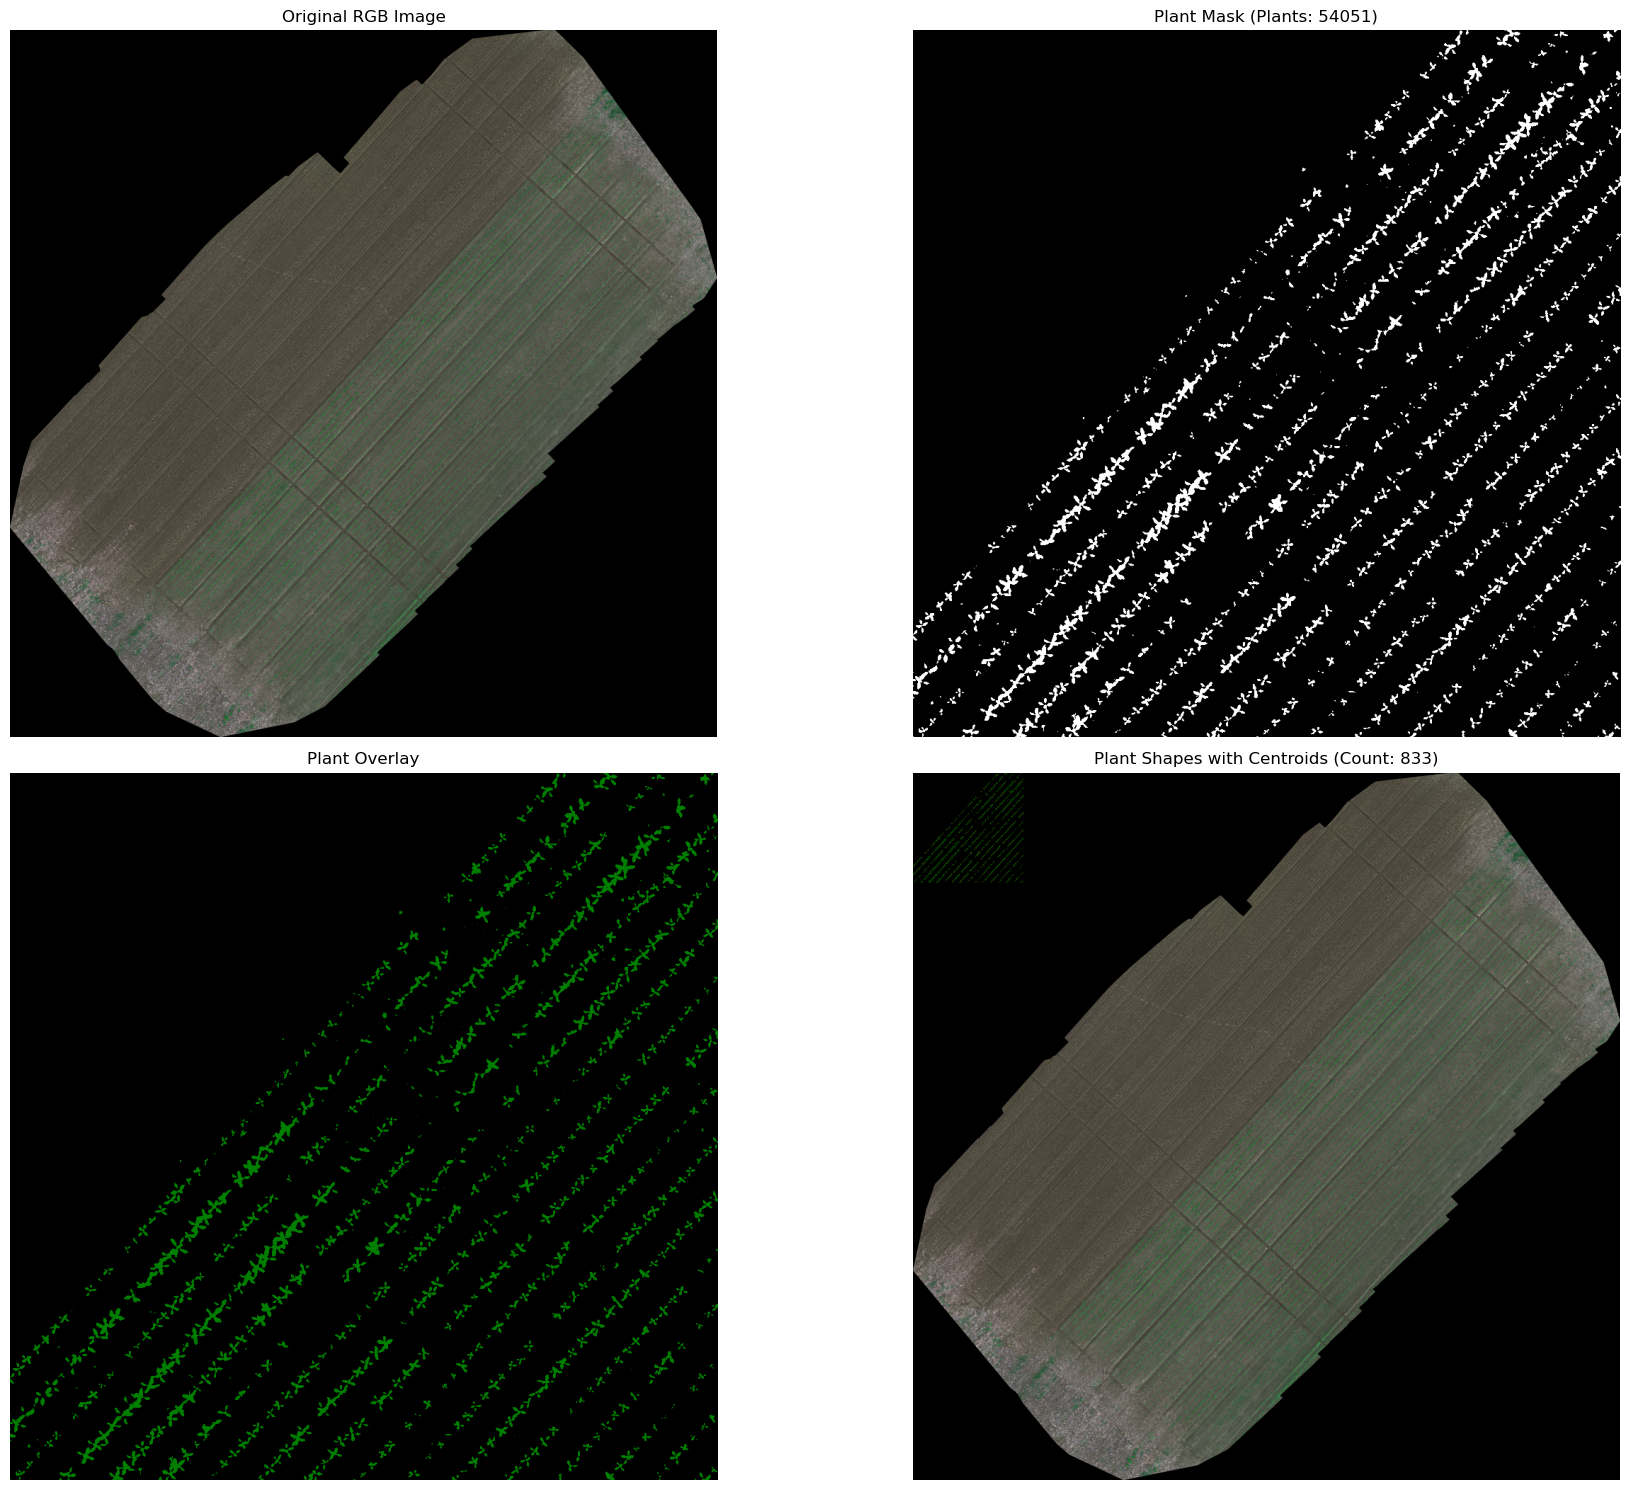

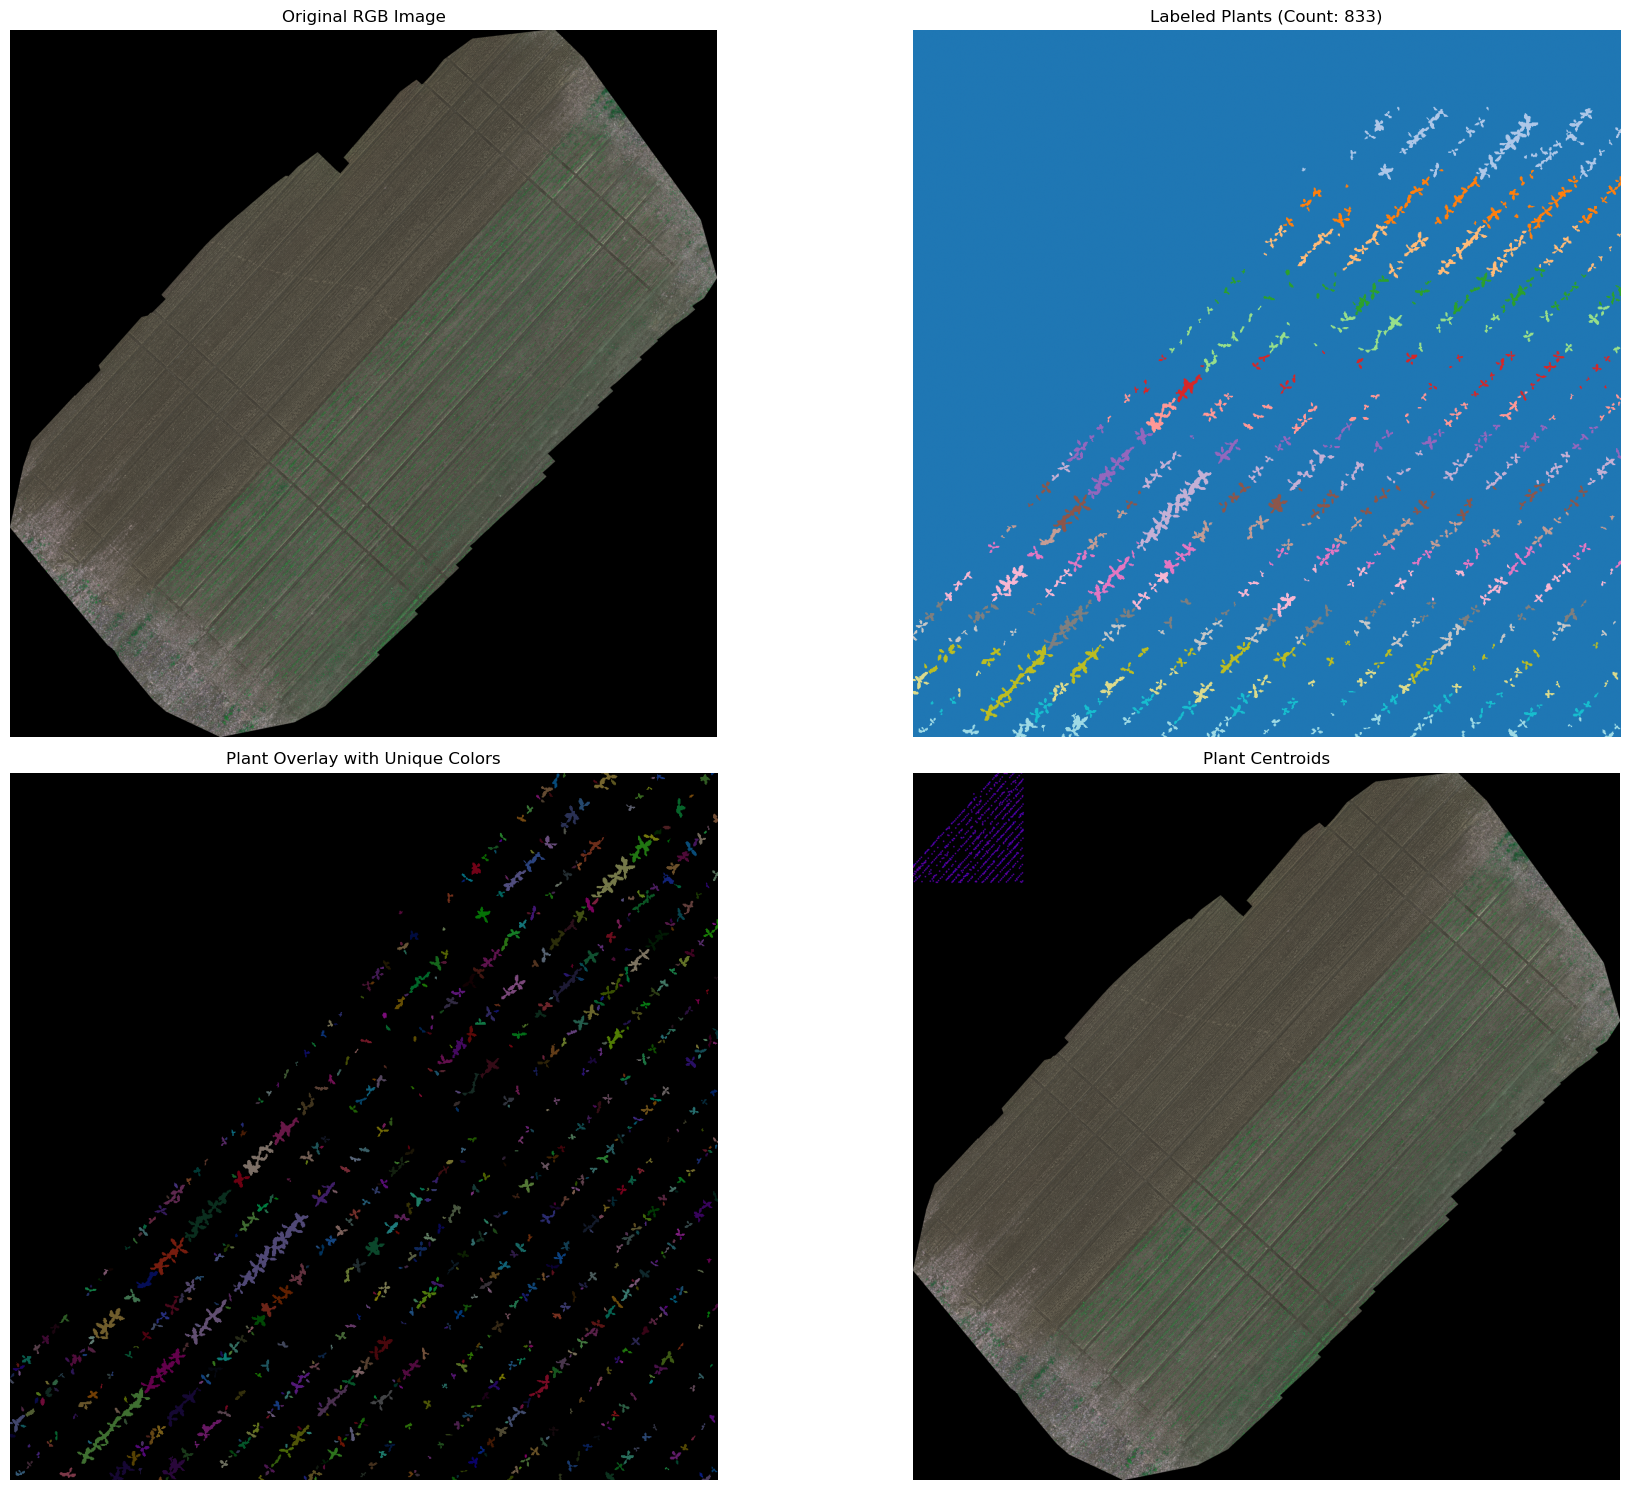

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
import cv2
from matplotlib.colors import LinearSegmentedColormap
from skimage.measure import label, regionprops
from scipy.ndimage import binary_erosion, binary_dilation

# Create output directory
output_dir = "plant_detection_results"
os.makedirs(output_dir, exist_ok=True)

# Set paths
dataset_path = os.path.expanduser("~/Dropbox/DEV/Data/RedEdge")
field_id = "002"
tif_path = os.path.join(dataset_path, field_id, "reflectance-tif")
png_path = os.path.join(dataset_path, field_id, "composite-png")

# Define NDVI vegetation detector class
class NDVIVegetationDetector:
    """
    Detects vegetation using NDVI (Normalized Difference Vegetation Index)
    """
    def __init__(self, threshold=0.35, red_idx=0, nir_idx=3):
        self.threshold = threshold
        self.nir_idx = nir_idx
        self.red_idx = red_idx

    def calculate_ndvi(self, image):
        """
        Calculate NDVI without thresholding
        
        Args:
            image: Tensor with shape [C, H, W] containing NIR and Red bands
            
        Returns:
            NDVI tensor
        """
        ndvi = (image[self.nir_idx] - image[self.red_idx]) / (image[self.nir_idx] + image[self.red_idx] + 1e-8)
        ndvi[torch.isnan(ndvi)] = 0
        return ndvi

    def get_vegetation_mask(self, ndvi):
        """
        Create binary vegetation mask based on NDVI threshold
        
        Args:
            ndvi: NDVI tensor
            
        Returns:
            Binary mask of vegetation
        """
        return (ndvi > self.threshold).type(torch.uint8) * 255

# Load multispectral image function
def load_multispectral_image(image_path, format='tif', channels=None):
    """
    Load a multispectral image from a directory structure or a single file
    
    Args:
        image_path: Path to the image file or directory
        format: Image format ('tif' or 'png')
        channels: List of channel names to load (default: R, G, B, NIR)
        
    Returns:
        Tensor with shape [C, H, W]
    """
    if channels is None:
        channels = ['R', 'G', 'B', 'NIR']

    if os.path.isdir(image_path):
        # Handle directory structure
        if format == 'tif':
            # For TIF format, load from reflectance-tif directory
            channel_tensors = []
            channel_files = {
                'R': 'transparent_reflectance_red.tif',
                'G': 'transparent_reflectance_green.tif',
                'B': 'transparent_reflectance_blue.tif',
                'NIR': 'transparent_reflectance_nir.tif',
                'RE': 'transparent_reflectance_rededge.tif'
            }

            for channel in channels:
                if channel not in channel_files:
                    raise ValueError(f"Channel {channel} not supported for TIF format")

                channel_path = os.path.join(image_path, channel_files[channel])

                if not os.path.exists(channel_path):
                    raise ValueError(f"Channel file {channel_path} not found")

                # Use PIL to open TIFF
                img = Image.open(channel_path)
                channel_array = np.array(img).astype(np.float32)

                # Handle single band images
                if channel_array.ndim == 2:
                    channel_tensor = torch.from_numpy(channel_array).float().unsqueeze(0)
                else:
                    # If the array is 3D with channels last, transpose to channels first
                    channel_array = np.transpose(channel_array, (2, 0, 1))
                    channel_tensor = torch.from_numpy(channel_array).float()

                channel_tensors.append(channel_tensor)

            # Stack channels
            image_tensor = torch.cat([t for t in channel_tensors])
        else:  # PNG format
            # For PNG format, load from composite-png directory
            channel_tensors = []

            for channel in channels:
                channel_path = os.path.join(image_path, f"{channel}.png")

                if not os.path.exists(channel_path):
                    raise ValueError(f"Channel file {channel_path} not found")

                img = Image.open(channel_path)
                channel_array = np.array(img).astype(np.float32)
                if channel_array.ndim == 3:
                    channel_array = channel_array[:,:,0]  # Take first channel if RGB
                channel_tensor = torch.from_numpy(channel_array).float().unsqueeze(0)

                channel_tensors.append(channel_tensor)

            # Stack channels
            image_tensor = torch.cat(channel_tensors)
    else:
        # Single file (e.g., TIFF with multiple bands)
        if image_path.lower().endswith(('.tif', '.tiff')):
            img = Image.open(image_path)
            if img.mode == 'I':  # Single band
                image_tensor = torch.from_numpy(np.array(img)).float().unsqueeze(0)
            else:
                img_array = np.array(img)
                if img_array.ndim == 3:
                    img_array = np.transpose(img_array, (2, 0, 1))
                image_tensor = torch.from_numpy(img_array).float()
        else:
            img = Image.open(image_path)
            img_array = np.array(img)
            if img_array.ndim == 3:
                img_array = np.transpose(img_array, (2, 0, 1))
            image_tensor = torch.from_numpy(img_array).float()

    # Normalize to [0, 1] range if needed
    if image_tensor.max() > 1.0:
        image_tensor /= 255.0

    return image_tensor

# Individual plant detection using connected components
def detect_individual_plants(veg_mask, min_area=10):
    """
    Detect individual plants using connected components analysis
    
    Args:
        veg_mask: Binary vegetation mask
        min_area: Minimum area (in pixels) to consider as a plant
        
    Returns:
        labeled_plants: Labeled image where each plant has a unique ID
        plant_properties: List of plant properties (area, bbox, centroid, etc.)
    """
    # Ensure mask is numpy array
    if isinstance(veg_mask, torch.Tensor):
        veg_mask = veg_mask.cpu().numpy()
    
    # Make sure mask is binary
    binary_mask = (veg_mask > 0).astype(np.uint8)
    
    # Optional: Apply morphological operations to clean up the mask
    # Uncomment these lines if you want to remove small noise or fill small holes
    # binary_mask = binary_erosion(binary_mask, iterations=1)
    # binary_mask = binary_dilation(binary_mask, iterations=1)
    
    # Label connected components
    labeled_plants = label(binary_mask)
    
    # Get region properties
    props = regionprops(labeled_plants)
    
    # Filter small regions
    valid_labels = []
    plant_properties = []
    
    for i, prop in enumerate(props):
        if prop.area >= min_area:
            valid_labels.append(prop.label)
            plant_properties.append({
                'label': prop.label,
                'area': prop.area,
                'bbox': prop.bbox,  # (min_row, min_col, max_row, max_col)
                'centroid': prop.centroid,
                'coords': prop.coords  # Coordinates of all pixels in the region
            })
    
    # Create filtered mask
    filtered_mask = np.isin(labeled_plants, valid_labels).astype(np.uint8)
    
    # Re-label to have consecutive labels
    final_labeled_plants = label(filtered_mask)
    
    return final_labeled_plants, plant_properties

# Visualization function with plant contours and centroids
def visualize_plants_with_centroids(rgb_image, plant_mask, plant_properties=None, output_path=None):
    """
    Visualize detected plants with their actual shapes and centroids
    
    Args:
        rgb_image: RGB image
        plant_mask: Binary plant mask
        plant_properties: List of plant properties
        output_path: Optional path to save visualization
        
    Returns:
        Paths to saved images
    """
    # Ensure RGB format
    if isinstance(rgb_image, torch.Tensor):
        rgb_img = rgb_image[:3].permute(1, 2, 0).cpu().numpy()
        if rgb_img.max() <= 1.0:
            rgb_img = (rgb_img * 255).astype(np.uint8)
    else:
        rgb_img = rgb_image.copy()
    
    # Create plant overlay (bright green color)
    if isinstance(plant_mask, torch.Tensor):
        plant_mask = plant_mask.cpu().numpy()
    
    # Make binary mask
    binary_mask = (plant_mask > 0).astype(np.uint8)
    
    # Create color overlay
    plant_overlay = np.zeros((*binary_mask.shape, 3), dtype=np.uint8)
    plant_overlay[binary_mask > 0] = [0, 255, 0]  # Bright green for plants
    
    # Create visualization figure
    plt.figure(figsize=(20, 15))
    
    # Plot original image
    plt.subplot(2, 2, 1)
    plt.imshow(rgb_img)
    plt.title('Original RGB Image')
    plt.axis('off')
    
    # Plot plant mask
    plt.subplot(2, 2, 2)
    plt.imshow(binary_mask, cmap='gray')
    plt.title(f'Plant Mask (Plants: {np.sum(binary_mask > 0)})')
    plt.axis('off')
    
    # Plot overlay
    plt.subplot(2, 2, 3)
    plt.imshow(rgb_img)
    plt.imshow(plant_overlay, alpha=0.5)
    plt.title('Plant Overlay')
    plt.axis('off')
    
    # Plot plants with contours and centroids
    plt.subplot(2, 2, 4)
    plt.imshow(rgb_img)
    
    if plant_properties is not None:
        # Create an image with contours and centroids
        centroid_img = rgb_img.copy()
        
        # Find contours of plants
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Draw centroids from properties
        for prop in plant_properties:
            # Get centroid
            y, x = prop['centroid']
            y, x = int(y), int(x)
            
            # Draw circle at centroid
            cv2.circle(centroid_img, (x, y), 2, (255, 0, 0), -1)  # Red circle
            
        # Draw contours
        cv2.drawContours(centroid_img, contours, -1, (0, 255, 0), 1)  # Green contours
        
        plt.imshow(centroid_img)
        plt.title(f'Plant Shapes with Centroids (Count: {len(plant_properties)})')
    else:
        # Just show the mask in color
        plt.imshow(plant_overlay)
        plt.title('Plant Overlay')
    
    plt.axis('off')
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300)
        
        # Also save individual files for leafmap split view
        base_path = os.path.splitext(output_path)[0]
        
        # Save RGB
        rgb_path = f"{base_path}_rgb.png"
        cv2.imwrite(rgb_path, cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR))
        
        # Save plant contours and centroids image
        contours_path = f"{base_path}_contours.png"
        
        # Create contours and centroids image
        if plant_properties is not None:
            contour_img = rgb_img.copy()
            
            # Find contours of plants
            contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            # Draw centroids from properties
            for prop in plant_properties:
                # Get centroid
                y, x = prop['centroid']
                y, x = int(y), int(x)
                
                # Draw circle at centroid
                cv2.circle(contour_img, (x, y), 5, (255, 0, 0), -1)  # Red circle with size 5
                
            # Draw contours
            cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)  # Green contours, thickness 2
            
            cv2.imwrite(contours_path, cv2.cvtColor(contour_img, cv2.COLOR_RGB2BGR))
        
        print(f"Saved visualization to {output_path}")
        print(f"RGB image: {rgb_path}")
        print(f"Contours image: {contours_path}")
        
        return rgb_path, contours_path
    
    plt.show()
    return None

# Create an advanced visualization with separate plant shapes
def visualize_plants_with_individual_shapes(rgb_image, labeled_plants, plant_properties, output_path=None):
    """
    Creates an advanced visualization with individual plant shapes highlighted in different colors
    
    Args:
        rgb_image: RGB image
        labeled_plants: Labeled plant image
        plant_properties: List of plant properties
        output_path: Optional path to save visualization
    
    Returns:
        Path to saved image
    """
    # Ensure RGB format
    if isinstance(rgb_image, torch.Tensor):
        rgb_img = rgb_image[:3].permute(1, 2, 0).cpu().numpy()
        if rgb_img.max() <= 1.0:
            rgb_img = (rgb_img * 255).astype(np.uint8)
    else:
        rgb_img = rgb_image.copy()
    
    # Convert labeled_plants to numpy if needed
    if isinstance(labeled_plants, torch.Tensor):
        labeled_plants = labeled_plants.cpu().numpy()
    
    # Create a random colormap for visualizing individual plants
    num_plants = len(plant_properties)
    np.random.seed(42)  # For reproducible colors
    colors = np.random.randint(0, 255, size=(num_plants + 1, 3), dtype=np.uint8)
    colors[0] = [0, 0, 0]  # Background is black
    
    # Create a colored image where each plant has a unique color
    plant_colored = np.zeros((*labeled_plants.shape, 3), dtype=np.uint8)
    for i in range(1, num_plants + 1):
        plant_colored[labeled_plants == i] = colors[i]
    
    # Create visualization figure
    plt.figure(figsize=(20, 15))
    
    # Plot original image
    plt.subplot(2, 2, 1)
    plt.imshow(rgb_img)
    plt.title('Original RGB Image')
    plt.axis('off')
    
    # Plot labeled plants
    plt.subplot(2, 2, 2)
    plt.imshow(labeled_plants, cmap='tab20')
    plt.title(f'Labeled Plants (Count: {num_plants})')
    plt.axis('off')
    
    # Plot RGB with plant overlay
    plt.subplot(2, 2, 3)
    plt.imshow(rgb_img)
    plt.imshow(plant_colored, alpha=0.5)
    plt.title('Plant Overlay with Unique Colors')
    plt.axis('off')
    
    # Plot centroids on RGB
    plt.subplot(2, 2, 4)
    centroid_img = rgb_img.copy()
    
    # Draw centroids
    for prop in plant_properties:
        # Get centroid
        y, x = prop['centroid']
        y, x = int(y), int(x)
        
        # Draw larger circle at centroid (red with blue border)
        cv2.circle(centroid_img, (x, y), 6, (0, 0, 255), 2)  # Blue border
        cv2.circle(centroid_img, (x, y), 4, (255, 0, 0), -1)  # Red fill
    
    plt.imshow(centroid_img)
    plt.title('Plant Centroids')
    plt.axis('off')
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300)
        
        # Create and save an image with both shapes and centroids
        shapes_centroids_path = f"{os.path.splitext(output_path)[0]}_shapes_centroids.png"
        
        # Create a new visualization with plant contours and centroids
        shapes_img = rgb_img.copy()
        
        # First, draw plant shapes
        binary_mask = (labeled_plants > 0).astype(np.uint8)
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(shapes_img, contours, -1, (0, 255, 0), 2)  # Green contours
        
        # Then, draw centroids
        for prop in plant_properties:
            y, x = prop['centroid']
            y, x = int(y), int(x)
            
            # Draw circle at centroid
            cv2.circle(shapes_img, (x, y), 5, (255, 0, 0), -1)  # Red circle
        
        cv2.imwrite(shapes_centroids_path, cv2.cvtColor(shapes_img, cv2.COLOR_RGB2BGR))
        
        print(f"Saved visualization to {output_path}")
        print(f"Shapes and centroids image: {shapes_centroids_path}")
        
        return shapes_centroids_path
    
    plt.show()
    return None

# Main execution code
print("Starting plant detection with shapes and centroids...")

# First, load the RGB.png for preview
rgb_file_path = os.path.join(png_path, "RGB.png")
if os.path.exists(rgb_file_path):
    # Load RGB directly using OpenCV
    rgb_image = cv2.imread(rgb_file_path)
    # Convert from BGR to RGB (OpenCV loads as BGR)
    rgb_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2RGB)
    print(f"Loaded RGB.png with shape: {rgb_image.shape}")
else:
    print(f"RGB.png not found at {rgb_file_path}")
    exit(1)  # Exit if RGB file not found

# Load multispectral TIFF data for NDVI calculation
if os.path.exists(tif_path):
    print("Loading multispectral TIFF data...")
    # Load multispectral data
    image = load_multispectral_image(tif_path, format="tif")
    print(f"Loaded multispectral data with shape: {image.shape}")
    
    # Option to use a smaller sample for faster processing
    use_sample = True
    if use_sample and image.shape[1] > 1000 and image.shape[2] > 1000:
        print("Using a sample portion of the image for faster processing...")
        # Extract a 1000x1000 sample from the center of the image
        center_h = image.shape[1] // 2
        center_w = image.shape[2] // 2
        sample_size = 1000
        image = image[:, 
                    center_h - sample_size//2:center_h + sample_size//2, 
                    center_w - sample_size//2:center_w + sample_size//2]
        print(f"Sample image shape: {image.shape}")
        
        # Also crop the RGB image to match
        rgb_h, rgb_w = rgb_image.shape[:2]
        rgb_center_h = rgb_h // 2
        rgb_center_w = rgb_w // 2
        
        # Calculate the scale factor between TIFF and RGB
        scale_h = rgb_h / image.shape[1]
        scale_w = rgb_w / image.shape[2]
        
        # Calculate the sample size in RGB image coordinates
        rgb_sample_h = int(sample_size * scale_h)
        rgb_sample_w = int(sample_size * scale_w)
        
        # Crop RGB image
        rgb_image = rgb_image[
            rgb_center_h - rgb_sample_h//2:rgb_center_h + rgb_sample_h//2,
            rgb_center_w - rgb_sample_w//2:rgb_center_w + rgb_sample_w//2
        ]
        print(f"Cropped RGB image shape: {rgb_image.shape}")
    
    # Calculate NDVI with the optimal threshold (0.35 as you specified)
    print("Calculating NDVI...")
    ndvi_detector = NDVIVegetationDetector(threshold=0.35)
    ndvi = ndvi_detector.calculate_ndvi(image)
    print(f"NDVI calculated. Min: {ndvi.min().item():.3f}, Max: {ndvi.max().item():.3f}")
    
    # Get vegetation mask
    veg_mask = ndvi_detector.get_vegetation_mask(ndvi)
    veg_pixels = (veg_mask > 0).sum().item()
    total_pixels = veg_mask.numel()
    veg_percentage = (veg_pixels / total_pixels) * 100
    print(f"Vegetation mask created. Vegetation pixels: {veg_pixels} ({veg_percentage:.2f}% of image)")
    
    # Detect individual plants
    print("Detecting individual plants...")
    labeled_plants, plant_properties = detect_individual_plants(veg_mask, min_area=10)
    print(f"Detected {len(plant_properties)} individual plants")
    
    # Create visualization with centroids
    print("Creating visualization with centroids...")
    output_path = os.path.join(output_dir, f"field_{field_id}_centroids.png")
    rgb_path, contours_path = visualize_plants_with_centroids(
        rgb_image,
        veg_mask,
        plant_properties,
        output_path
    )
    
    # Create advanced visualization with individual plant shapes
    print("Creating advanced visualization with individual plant shapes...")
    shapes_output_path = os.path.join(output_dir, f"field_{field_id}_shapes.png")
    shapes_centroids_path = visualize_plants_with_individual_shapes(
        rgb_image,
        labeled_plants,
        plant_properties,
        shapes_output_path
    )
    
    print("\nProcessing complete!")
    print(f"Generated visualizations:")
    print(f"1. Plant Centroids: {output_path}")
    print(f"2. Plant Contours: {contours_path}")
    print(f"3. Individual Plant Shapes: {shapes_output_path}")
    print(f"4. Shapes and Centroids: {shapes_centroids_path}")
else:
    print(f"TIFF directory not found at {tif_path}")

## Create geojson from the extracted plant shapes

In [5]:
pip install rasterio pyproj folium

Note: you may need to restart the kernel to use updated packages.


Starting plant detection with geospatial analysis...
Loaded RGB.png with shape: (6405, 6403, 3)
Loading multispectral TIFF data...
Loaded multispectral data with shape: torch.Size([4, 6405, 6403])
Using a sample portion of the image for faster processing...
Sample image shape: torch.Size([4, 1000, 1000])
Cropped RGB image shape: (6404, 6402, 3)
Calculating NDVI...
NDVI calculated. Min: -0.144, Max: 0.776
Vegetation mask created. Vegetation pixels: 54051 (5.41% of image)
Detecting individual plants...
Detected 833 individual plants
Creating visualization with centroids...
Saved visualization to plant_detection_results/field_002_centroids.png
RGB image: plant_detection_results/field_002_centroids_rgb.png
Contours image: plant_detection_results/field_002_centroids_contours.png
Creating advanced visualization with individual plant shapes...
Saved visualization to plant_detection_results/field_002_shapes.png
Shapes and centroids image: plant_detection_results/field_002_shapes_shapes_centroi

Map saved as: plant_detection_results/field_002_plant_map.html

Processing complete!
Generated visualizations:
1. Plant Centroids: plant_detection_results/field_002_centroids.png
2. Plant Contours: plant_detection_results/field_002_centroids_contours.png
3. Individual Plant Shapes: plant_detection_results/field_002_shapes.png
4. Shapes and Centroids: plant_detection_results/field_002_shapes_shapes_centroids.png
5. Plant GeoJSON: plant_detection_results/field_002_plants.geojson
6. Interactive Map: plant_detection_results/field_002_plant_map.html


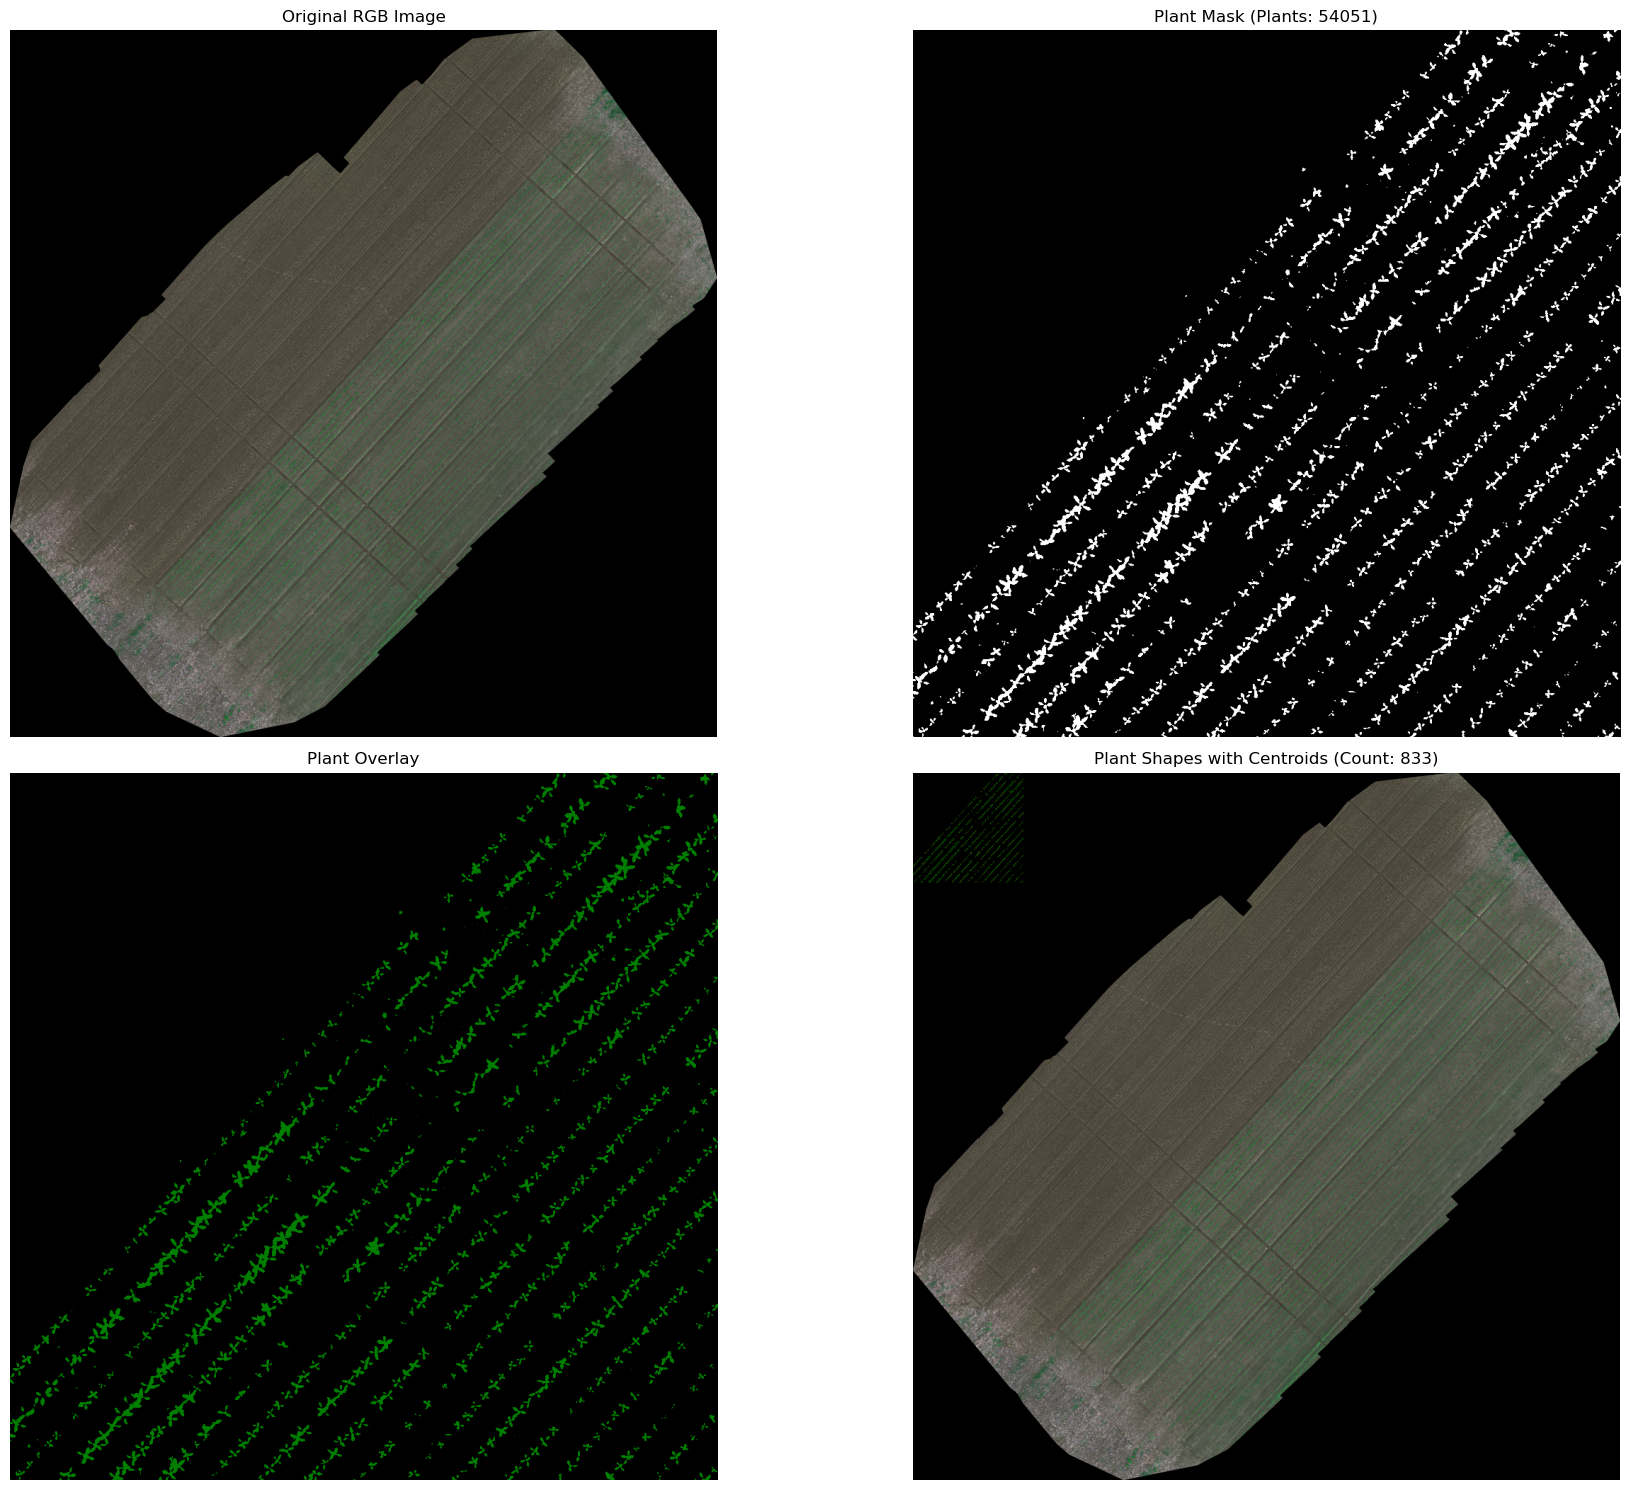

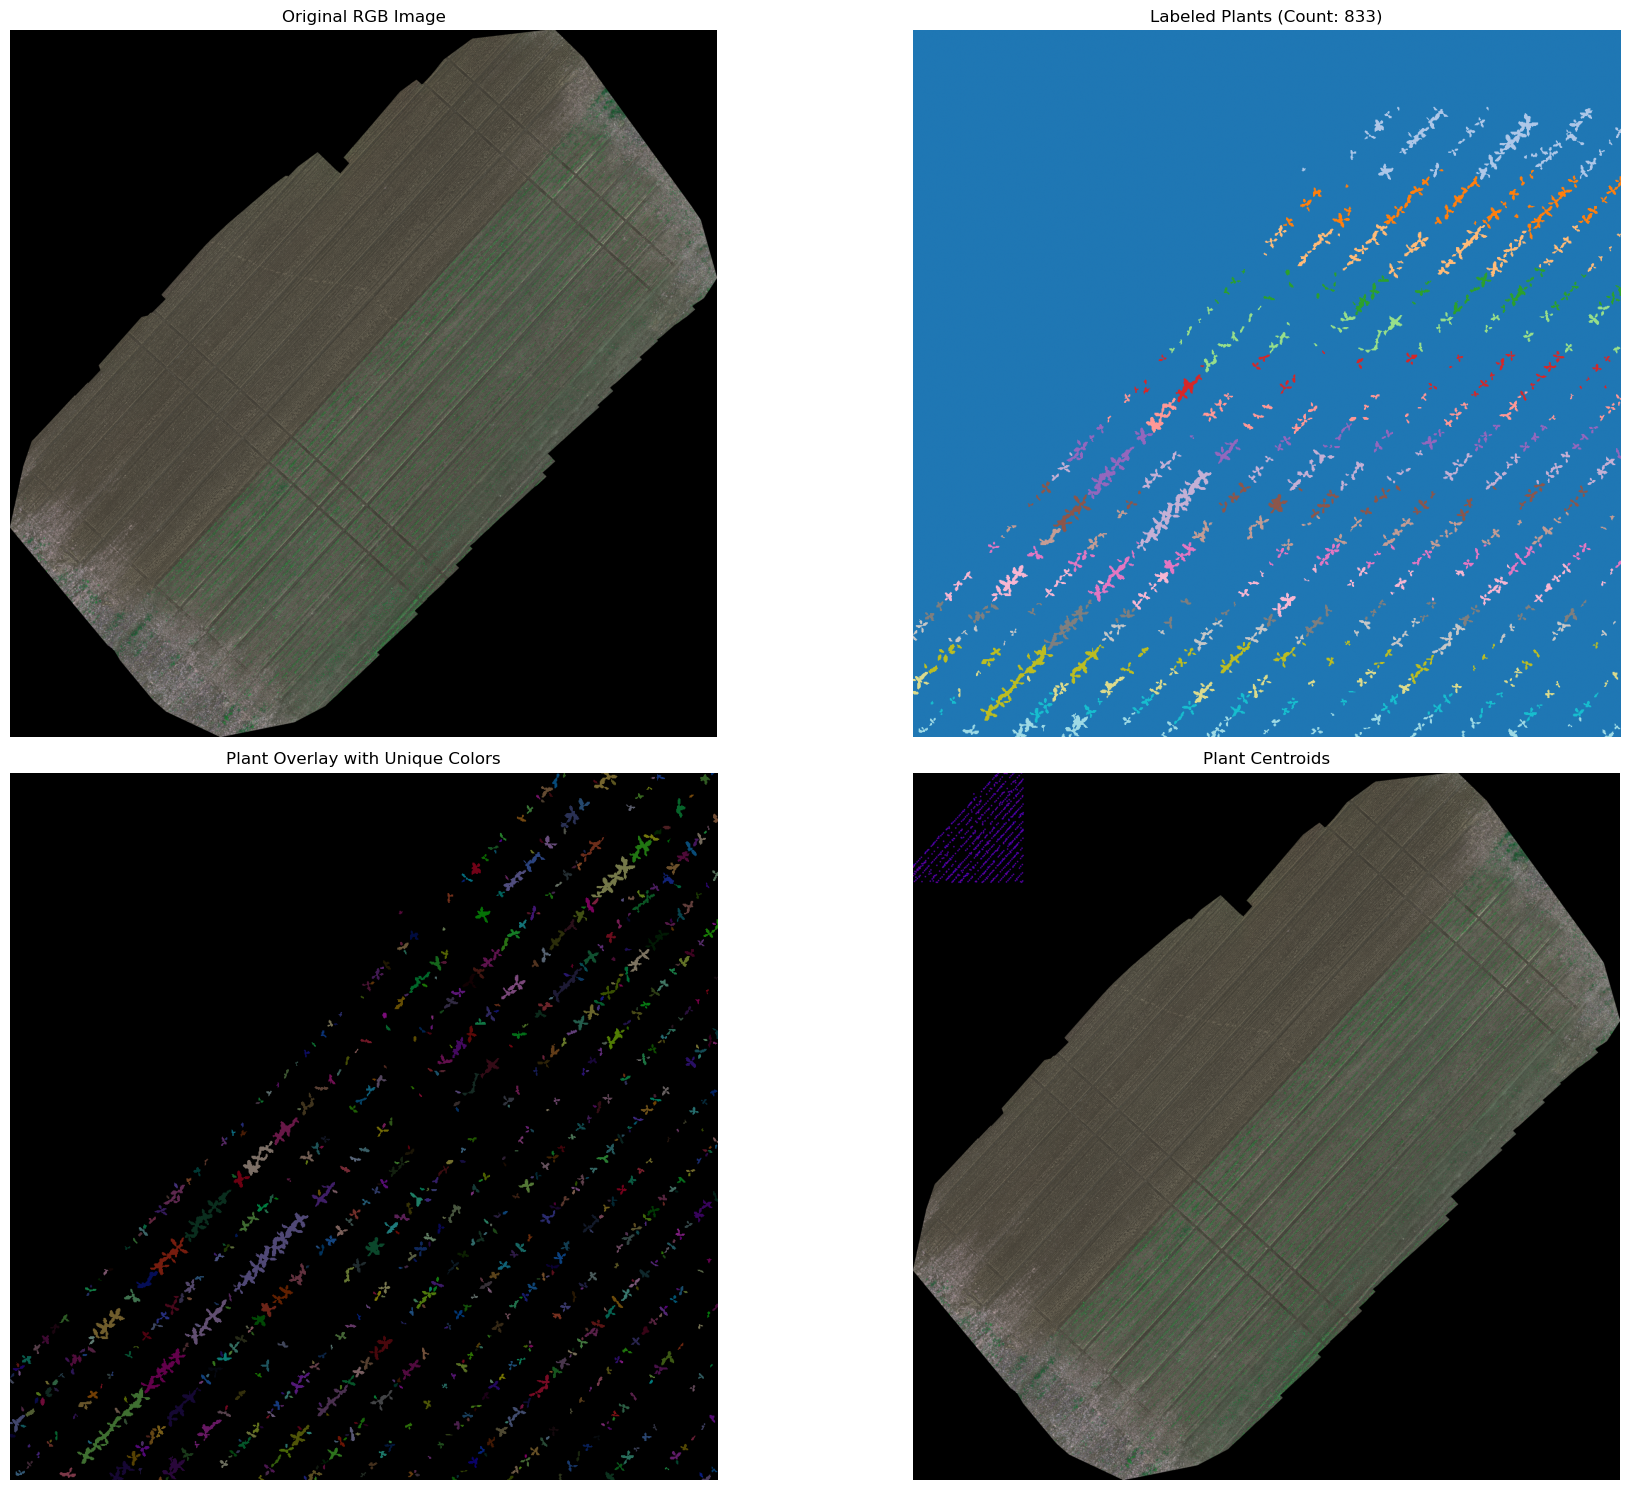

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
import cv2
from matplotlib.colors import LinearSegmentedColormap
from skimage.measure import label, regionprops
from scipy.ndimage import binary_erosion, binary_dilation
import json
from datetime import datetime

# Create output directory
output_dir = "plant_detection_results"
os.makedirs(output_dir, exist_ok=True)

# Set paths
dataset_path = os.path.expanduser("~/Dropbox/DEV/Data/RedEdge")
field_id = "002"
tif_path = os.path.join(dataset_path, field_id, "reflectance-tif")
png_path = os.path.join(dataset_path, field_id, "composite-png")

# Define NDVI vegetation detector class
class NDVIVegetationDetector:
    """
    Detects vegetation using NDVI (Normalized Difference Vegetation Index)
    """
    def __init__(self, threshold=0.35, red_idx=0, nir_idx=3):
        self.threshold = threshold
        self.nir_idx = nir_idx
        self.red_idx = red_idx

    def calculate_ndvi(self, image):
        """
        Calculate NDVI without thresholding
        
        Args:
            image: Tensor with shape [C, H, W] containing NIR and Red bands
            
        Returns:
            NDVI tensor
        """
        ndvi = (image[self.nir_idx] - image[self.red_idx]) / (image[self.nir_idx] + image[self.red_idx] + 1e-8)
        ndvi[torch.isnan(ndvi)] = 0
        return ndvi

    def get_vegetation_mask(self, ndvi):
        """
        Create binary vegetation mask based on NDVI threshold
        
        Args:
            ndvi: NDVI tensor
            
        Returns:
            Binary mask of vegetation
        """
        return (ndvi > self.threshold).type(torch.uint8) * 255

# Load multispectral image function
def load_multispectral_image(image_path, format='tif', channels=None):
    """
    Load a multispectral image from a directory structure or a single file
    
    Args:
        image_path: Path to the image file or directory
        format: Image format ('tif' or 'png')
        channels: List of channel names to load (default: R, G, B, NIR)
        
    Returns:
        Tensor with shape [C, H, W]
    """
    if channels is None:
        channels = ['R', 'G', 'B', 'NIR']

    if os.path.isdir(image_path):
        # Handle directory structure
        if format == 'tif':
            # For TIF format, load from reflectance-tif directory
            channel_tensors = []
            channel_files = {
                'R': 'transparent_reflectance_red.tif',
                'G': 'transparent_reflectance_green.tif',
                'B': 'transparent_reflectance_blue.tif',
                'NIR': 'transparent_reflectance_nir.tif',
                'RE': 'transparent_reflectance_rededge.tif'
            }

            for channel in channels:
                if channel not in channel_files:
                    raise ValueError(f"Channel {channel} not supported for TIF format")

                channel_path = os.path.join(image_path, channel_files[channel])

                if not os.path.exists(channel_path):
                    raise ValueError(f"Channel file {channel_path} not found")

                # Use PIL to open TIFF
                img = Image.open(channel_path)
                channel_array = np.array(img).astype(np.float32)

                # Handle single band images
                if channel_array.ndim == 2:
                    channel_tensor = torch.from_numpy(channel_array).float().unsqueeze(0)
                else:
                    # If the array is 3D with channels last, transpose to channels first
                    channel_array = np.transpose(channel_array, (2, 0, 1))
                    channel_tensor = torch.from_numpy(channel_array).float()

                channel_tensors.append(channel_tensor)

            # Stack channels
            image_tensor = torch.cat([t for t in channel_tensors])
        else:  # PNG format
            # For PNG format, load from composite-png directory
            channel_tensors = []

            for channel in channels:
                channel_path = os.path.join(image_path, f"{channel}.png")

                if not os.path.exists(channel_path):
                    raise ValueError(f"Channel file {channel_path} not found")

                img = Image.open(channel_path)
                channel_array = np.array(img).astype(np.float32)
                if channel_array.ndim == 3:
                    channel_array = channel_array[:,:,0]  # Take first channel if RGB
                channel_tensor = torch.from_numpy(channel_array).float().unsqueeze(0)

                channel_tensors.append(channel_tensor)

            # Stack channels
            image_tensor = torch.cat(channel_tensors)
    else:
        # Single file (e.g., TIFF with multiple bands)
        if image_path.lower().endswith(('.tif', '.tiff')):
            img = Image.open(image_path)
            if img.mode == 'I':  # Single band
                image_tensor = torch.from_numpy(np.array(img)).float().unsqueeze(0)
            else:
                img_array = np.array(img)
                if img_array.ndim == 3:
                    img_array = np.transpose(img_array, (2, 0, 1))
                image_tensor = torch.from_numpy(img_array).float()
        else:
            img = Image.open(image_path)
            img_array = np.array(img)
            if img_array.ndim == 3:
                img_array = np.transpose(img_array, (2, 0, 1))
            image_tensor = torch.from_numpy(img_array).float()

    # Normalize to [0, 1] range if needed
    if image_tensor.max() > 1.0:
        image_tensor /= 255.0

    return image_tensor

# Individual plant detection using connected components
def detect_individual_plants(veg_mask, min_area=10):
    """
    Detect individual plants using connected components analysis
    
    Args:
        veg_mask: Binary vegetation mask
        min_area: Minimum area (in pixels) to consider as a plant
        
    Returns:
        labeled_plants: Labeled image where each plant has a unique ID
        plant_properties: List of plant properties (area, bbox, centroid, etc.)
    """
    # Ensure mask is numpy array
    if isinstance(veg_mask, torch.Tensor):
        veg_mask = veg_mask.cpu().numpy()
    
    # Make sure mask is binary
    binary_mask = (veg_mask > 0).astype(np.uint8)
    
    # Optional: Apply morphological operations to clean up the mask
    # Uncomment these lines if you want to remove small noise or fill small holes
    # binary_mask = binary_erosion(binary_mask, iterations=1)
    # binary_mask = binary_dilation(binary_mask, iterations=1)
    
    # Label connected components
    labeled_plants = label(binary_mask)
    
    # Get region properties
    props = regionprops(labeled_plants)
    
    # Filter small regions
    valid_labels = []
    plant_properties = []
    
    for i, prop in enumerate(props):
        if prop.area >= min_area:
            valid_labels.append(prop.label)
            plant_properties.append({
                'label': prop.label,
                'area': prop.area,
                'bbox': prop.bbox,  # (min_row, min_col, max_row, max_col)
                'centroid': prop.centroid,
                'coords': prop.coords  # Coordinates of all pixels in the region
            })
    
    # Create filtered mask
    filtered_mask = np.isin(labeled_plants, valid_labels).astype(np.uint8)
    
    # Re-label to have consecutive labels
    final_labeled_plants = label(filtered_mask)
    
    return final_labeled_plants, plant_properties

# Visualization function with plant contours and centroids
def visualize_plants_with_centroids(rgb_image, plant_mask, plant_properties=None, output_path=None):
    """
    Visualize detected plants with their actual shapes and centroids
    
    Args:
        rgb_image: RGB image
        plant_mask: Binary plant mask
        plant_properties: List of plant properties
        output_path: Optional path to save visualization
        
    Returns:
        Paths to saved images
    """
    # Ensure RGB format
    if isinstance(rgb_image, torch.Tensor):
        rgb_img = rgb_image[:3].permute(1, 2, 0).cpu().numpy()
        if rgb_img.max() <= 1.0:
            rgb_img = (rgb_img * 255).astype(np.uint8)
    else:
        rgb_img = rgb_image.copy()
    
    # Create plant overlay (bright green color)
    if isinstance(plant_mask, torch.Tensor):
        plant_mask = plant_mask.cpu().numpy()
    
    # Make binary mask
    binary_mask = (plant_mask > 0).astype(np.uint8)
    
    # Create color overlay
    plant_overlay = np.zeros((*binary_mask.shape, 3), dtype=np.uint8)
    plant_overlay[binary_mask > 0] = [0, 255, 0]  # Bright green for plants
    
    # Create visualization figure
    plt.figure(figsize=(20, 15))
    
    # Plot original image
    plt.subplot(2, 2, 1)
    plt.imshow(rgb_img)
    plt.title('Original RGB Image')
    plt.axis('off')
    
    # Plot plant mask
    plt.subplot(2, 2, 2)
    plt.imshow(binary_mask, cmap='gray')
    plt.title(f'Plant Mask (Plants: {np.sum(binary_mask > 0)})')
    plt.axis('off')
    
    # Plot overlay
    plt.subplot(2, 2, 3)
    plt.imshow(rgb_img)
    plt.imshow(plant_overlay, alpha=0.5)
    plt.title('Plant Overlay')
    plt.axis('off')
    
    # Plot plants with contours and centroids
    plt.subplot(2, 2, 4)
    plt.imshow(rgb_img)
    
    if plant_properties is not None:
        # Create an image with contours and centroids
        centroid_img = rgb_img.copy()
        
        # Find contours of plants
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # Draw centroids from properties
        for prop in plant_properties:
            # Get centroid
            y, x = prop['centroid']
            y, x = int(y), int(x)
            
            # Draw circle at centroid
            cv2.circle(centroid_img, (x, y), 2, (255, 0, 0), -1)  # Red circle
            
        # Draw contours
        cv2.drawContours(centroid_img, contours, -1, (0, 255, 0), 1)  # Green contours
        
        plt.imshow(centroid_img)
        plt.title(f'Plant Shapes with Centroids (Count: {len(plant_properties)})')
    else:
        # Just show the mask in color
        plt.imshow(plant_overlay)
        plt.title('Plant Overlay')
    
    plt.axis('off')
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300)
        
        # Also save individual files for leafmap split view
        base_path = os.path.splitext(output_path)[0]
        
        # Save RGB
        rgb_path = f"{base_path}_rgb.png"
        cv2.imwrite(rgb_path, cv2.cvtColor(rgb_img, cv2.COLOR_RGB2BGR))
        
        # Save plant contours and centroids image
        contours_path = f"{base_path}_contours.png"
        
        # Create contours and centroids image
        if plant_properties is not None:
            contour_img = rgb_img.copy()
            
            # Find contours of plants
            contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            # Draw centroids from properties
            for prop in plant_properties:
                # Get centroid
                y, x = prop['centroid']
                y, x = int(y), int(x)
                
                # Draw circle at centroid
                cv2.circle(contour_img, (x, y), 5, (255, 0, 0), -1)  # Red circle with size 5
                
            # Draw contours
            cv2.drawContours(contour_img, contours, -1, (0, 255, 0), 2)  # Green contours, thickness 2
            
            cv2.imwrite(contours_path, cv2.cvtColor(contour_img, cv2.COLOR_RGB2BGR))
        
        print(f"Saved visualization to {output_path}")
        print(f"RGB image: {rgb_path}")
        print(f"Contours image: {contours_path}")
        
        return rgb_path, contours_path
    
    plt.show()
    return None

# Create an advanced visualization with separate plant shapes
def visualize_plants_with_individual_shapes(rgb_image, labeled_plants, plant_properties, output_path=None):
    """
    Creates an advanced visualization with individual plant shapes highlighted in different colors
    
    Args:
        rgb_image: RGB image
        labeled_plants: Labeled plant image
        plant_properties: List of plant properties
        output_path: Optional path to save visualization
    
    Returns:
        Path to saved image
    """
    # Ensure RGB format
    if isinstance(rgb_image, torch.Tensor):
        rgb_img = rgb_image[:3].permute(1, 2, 0).cpu().numpy()
        if rgb_img.max() <= 1.0:
            rgb_img = (rgb_img * 255).astype(np.uint8)
    else:
        rgb_img = rgb_image.copy()
    
    # Convert labeled_plants to numpy if needed
    if isinstance(labeled_plants, torch.Tensor):
        labeled_plants = labeled_plants.cpu().numpy()
    
    # Create a random colormap for visualizing individual plants
    num_plants = len(plant_properties)
    np.random.seed(42)  # For reproducible colors
    colors = np.random.randint(0, 255, size=(num_plants + 1, 3), dtype=np.uint8)
    colors[0] = [0, 0, 0]  # Background is black
    
    # Create a colored image where each plant has a unique color
    plant_colored = np.zeros((*labeled_plants.shape, 3), dtype=np.uint8)
    for i in range(1, num_plants + 1):
        plant_colored[labeled_plants == i] = colors[i]
    
    # Create visualization figure
    plt.figure(figsize=(20, 15))
    
    # Plot original image
    plt.subplot(2, 2, 1)
    plt.imshow(rgb_img)
    plt.title('Original RGB Image')
    plt.axis('off')
    
    # Plot labeled plants
    plt.subplot(2, 2, 2)
    plt.imshow(labeled_plants, cmap='tab20')
    plt.title(f'Labeled Plants (Count: {num_plants})')
    plt.axis('off')
    
    # Plot RGB with plant overlay
    plt.subplot(2, 2, 3)
    plt.imshow(rgb_img)
    plt.imshow(plant_colored, alpha=0.5)
    plt.title('Plant Overlay with Unique Colors')
    plt.axis('off')
    
    # Plot centroids on RGB
    plt.subplot(2, 2, 4)
    centroid_img = rgb_img.copy()
    
    # Draw centroids
    for prop in plant_properties:
        # Get centroid
        y, x = prop['centroid']
        y, x = int(y), int(x)
        
        # Draw larger circle at centroid (red with blue border)
        cv2.circle(centroid_img, (x, y), 6, (0, 0, 255), 2)  # Blue border
        cv2.circle(centroid_img, (x, y), 4, (255, 0, 0), -1)  # Red fill
    
    plt.imshow(centroid_img)
    plt.title('Plant Centroids')
    plt.axis('off')
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=300)
        
        # Create and save an image with both shapes and centroids
        shapes_centroids_path = f"{os.path.splitext(output_path)[0]}_shapes_centroids.png"
        
        # Create a new visualization with plant contours and centroids
        shapes_img = rgb_img.copy()
        
        # First, draw plant shapes
        binary_mask = (labeled_plants > 0).astype(np.uint8)
        contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(shapes_img, contours, -1, (0, 255, 0), 2)  # Green contours
        
        # Then, draw centroids
        for prop in plant_properties:
            y, x = prop['centroid']
            y, x = int(y), int(x)
            
            # Draw circle at centroid
            cv2.circle(shapes_img, (x, y), 5, (255, 0, 0), -1)  # Red circle
        
        cv2.imwrite(shapes_centroids_path, cv2.cvtColor(shapes_img, cv2.COLOR_RGB2BGR))
        
        print(f"Saved visualization to {output_path}")
        print(f"Shapes and centroids image: {shapes_centroids_path}")
        
        return shapes_centroids_path
    
    plt.show()
    return None

# Define function to create GeoJSON for plants with proper georeferencing
def create_plant_geojson(plant_properties, output_dir, tif_path):
    """
    Create a GeoJSON file for the extracted plants using proper georeferencing from TIF
    
    Args:
        plant_properties: List of plant properties
        output_dir: Directory to save the GeoJSON file
        tif_path: Path to the georeferenced TIF file
        
    Returns:
        Path to the saved GeoJSON file and center coordinates
    """
    import rasterio
    import pyproj
    
    # Extract georeferencing from the TIF file
    with rasterio.open(tif_path) as src:
        # Get the transformation and coordinate reference system
        transform = src.transform
        crs = src.crs
        
        print(f"Source CRS: {crs}")
        print(f"Transform: {transform}")
        
        # Create a transformer to convert from UTM to WGS84 (for Folium)
        utm_to_wgs84 = pyproj.Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
        
        # Create features list
        features = []
        
        # Process each plant
        for i, prop in enumerate(plant_properties):
            # Get centroid in pixel coordinates
            row, col = prop['centroid']
            
            # Convert pixel to UTM coordinates using the image's geotransform
            x, y = rasterio.transform.xy(transform, row, col)
            
            # Convert UTM to WGS84 (longitude, latitude)
            lon, lat = utm_to_wgs84.transform(x, y)
            
            # Create GeoJSON feature (using WGS84 coordinates)
            feature = {
                "type": "Feature",
                "geometry": {
                    "type": "Point",
                    "coordinates": [lon, lat]
                },
                "properties": {
                    "id": i,
                    "plant_id": prop['label'],
                    "area": prop['area'],
                    "bbox": [int(x) for x in prop['bbox']],
                    "centroid_px": [float(row), float(col)],
                    "utm_coords": [float(x), float(y)]
                }
            }
            
            features.append(feature)
        
        # Get center for the map
        center_row = src.height / 2
        center_col = src.width / 2
        center_x, center_y = rasterio.transform.xy(transform, center_row, center_col)
        center_lon, center_lat = utm_to_wgs84.transform(center_x, center_y)
        center_coords = [center_lon, center_lat]
        
        # Create GeoJSON structure
        geojson = {
            "type": "FeatureCollection",
            "name": f"Plants from field {field_id}",
            "features": features,
            "properties": {
                "created": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
                "plant_count": len(features),
                "center": center_coords,
                "original_crs": str(crs),
                "original_bounds": {
                    "utm": {
                        "east": src.bounds.left,
                        "west": src.bounds.right,
                        "north": src.bounds.top,
                        "south": src.bounds.bottom
                    }
                }
            }
        }
        
        # Save to file
        geojson_path = os.path.join(output_dir, f"field_{field_id}_plants.geojson")
        with open(geojson_path, 'w') as f:
            json.dump(geojson, f, indent=2)
        
        print(f"Created GeoJSON file with {len(features)} plants: {geojson_path}")
        return geojson_path, center_coords

# Define function to display plants on a map with proper attribution
def display_plants_on_map(geojson_path, center_coords):
    """
    Display plants on an interactive map
    
    Args:
        geojson_path: Path to the GeoJSON file
        center_coords: Center coordinates [longitude, latitude] for the map
    """
    import folium
    
    # Load GeoJSON
    with open(geojson_path, 'r') as f:
        geojson_data = json.load(f)
    
    # Create map centered on the field
    m = folium.Map(
        location=[center_coords[1], center_coords[0]], 
        zoom_start=19,
        control_scale=True
    )
    
    # Add satellite imagery with proper attribution
    folium.TileLayer(
        tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
        attr="Esri World Imagery",
        name="Satellite"
    ).add_to(m)
    
    # Add GeoJSON layer
    folium.GeoJson(
        geojson_data,
        name="Plants",
        marker=folium.CircleMarker(radius=3, fill_color="#00ff00", color="#00ff00", weight=1),
        tooltip=folium.features.GeoJsonTooltip(
            fields=['id', 'plant_id', 'area'],
            aliases=['ID', 'Plant ID', 'Area (pixels)'],
            localize=True
        )
    ).add_to(m)
    
    # Add marker for center
    folium.Marker(
        location=[center_coords[1], center_coords[0]],
        popup="Field Center",
        icon=folium.Icon(color="red", icon="info-sign")
    ).add_to(m)
    
    # Add tile layer control
    folium.TileLayer(
        'cartodbpositron', 
        name='Light Map', 
        attr='CartoDB Positron'
    ).add_to(m)
    
    folium.TileLayer(
        'openstreetmap', 
        name='OpenStreetMap',
        attr='OpenStreetMap'
    ).add_to(m)
    
    folium.LayerControl().add_to(m)
    
    # Display map
    try:
        from IPython.display import display
        display(m)
    except ImportError:
        print("IPython display not available. Map will be saved as HTML file.")
    
    return m

# Main execution code
def main():
    print("Starting plant detection with geospatial analysis...")

    # First, load the RGB.png for preview
    rgb_file_path = os.path.join(png_path, "RGB.png")
    if os.path.exists(rgb_file_path):
        # Load RGB directly using OpenCV
        rgb_image = cv2.imread(rgb_file_path)
        # Convert from BGR to RGB (OpenCV loads as BGR)
        rgb_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2RGB)
        print(f"Loaded RGB.png with shape: {rgb_image.shape}")
    else:
        print(f"RGB.png not found at {rgb_file_path}")
        return  # Exit if RGB file not found

    # Load multispectral TIFF data for NDVI calculation
    if os.path.exists(tif_path):
        print("Loading multispectral TIFF data...")
        # Load multispectral data
        image = load_multispectral_image(tif_path, format="tif")
        print(f"Loaded multispectral data with shape: {image.shape}")
        
        # Option to use a smaller sample for faster processing
        use_sample = True
        if use_sample and image.shape[1] > 1000 and image.shape[2] > 1000:
            print("Using a sample portion of the image for faster processing...")
            # Extract a 1000x1000 sample from the center of the image
            center_h = image.shape[1] // 2
            center_w = image.shape[2] // 2
            sample_size = 1000
            image = image[:, 
                        center_h - sample_size//2:center_h + sample_size//2, 
                        center_w - sample_size//2:center_w + sample_size//2]
            print(f"Sample image shape: {image.shape}")
            
            # Also crop the RGB image to match
            rgb_h, rgb_w = rgb_image.shape[:2]
            rgb_center_h = rgb_h // 2
            rgb_center_w = rgb_w // 2
            
            # Calculate the scale factor between TIFF and RGB
            scale_h = rgb_h / image.shape[1]
            scale_w = rgb_w / image.shape[2]
            
            # Calculate the sample size in RGB image coordinates
            rgb_sample_h = int(sample_size * scale_h)
            rgb_sample_w = int(sample_size * scale_w)
            
            # Crop RGB image
            rgb_image = rgb_image[
                rgb_center_h - rgb_sample_h//2:rgb_center_h + rgb_sample_h//2,
                rgb_center_w - rgb_sample_w//2:rgb_center_w + rgb_sample_w//2
            ]
            print(f"Cropped RGB image shape: {rgb_image.shape}")
        
        # Calculate NDVI with the optimal threshold (0.35 as specified)
        print("Calculating NDVI...")
        ndvi_detector = NDVIVegetationDetector(threshold=0.35)
        ndvi = ndvi_detector.calculate_ndvi(image)
        print(f"NDVI calculated. Min: {ndvi.min().item():.3f}, Max: {ndvi.max().item():.3f}")
        
        # Get vegetation mask
        veg_mask = ndvi_detector.get_vegetation_mask(ndvi)
        veg_pixels = (veg_mask > 0).sum().item()
        total_pixels = veg_mask.numel()
        veg_percentage = (veg_pixels / total_pixels) * 100
        print(f"Vegetation mask created. Vegetation pixels: {veg_pixels} ({veg_percentage:.2f}% of image)")
        
        # Detect individual plants
        print("Detecting individual plants...")
        labeled_plants, plant_properties = detect_individual_plants(veg_mask, min_area=10)
        print(f"Detected {len(plant_properties)} individual plants")
        
        # Create visualization with centroids
        print("Creating visualization with centroids...")
        output_path = os.path.join(output_dir, f"field_{field_id}_centroids.png")
        rgb_path, contours_path = visualize_plants_with_centroids(
            rgb_image,
            veg_mask,
            plant_properties,
            output_path
        )
        
        # Create advanced visualization with individual plant shapes
        print("Creating advanced visualization with individual plant shapes...")
        shapes_output_path = os.path.join(output_dir, f"field_{field_id}_shapes.png")
        shapes_centroids_path = visualize_plants_with_individual_shapes(
            rgb_image,
            labeled_plants,
            plant_properties,
            shapes_output_path
        )
        
        # Create GeoJSON and display map
        try:
            print("Creating GeoJSON for plants with proper georeferencing...")
            
            # Path to the georeferenced TIF file
            geotif_path = os.path.join(tif_path, "transparent_reflectance_nir.tif")
            
            if not os.path.exists(geotif_path):
                raise FileNotFoundError(f"TIF file not found at {geotif_path}")
            
            # Make sure needed packages are installed
            try:
                import rasterio
                import pyproj
            except ImportError:
                print("Required packages rasterio and pyproj not found.")
                print("Please install them with: pip install rasterio pyproj")
                return
            
            # Create GeoJSON
            geojson_path, center_coords = create_plant_geojson(plant_properties, output_dir, geotif_path)
            
            # Display on map
            print("Displaying plants on map...")
            try:
                import folium
                m = display_plants_on_map(geojson_path, center_coords)
                
                # Save map as HTML
                map_path = os.path.join(output_dir, f"field_{field_id}_plant_map.html")
                m.save(map_path)
                print(f"Map saved as: {map_path}")
            except ImportError:
                print("Folium package not installed. Please install with: pip install folium")
                print("GeoJSON file was still created at: {geojson_path}")
            
        except Exception as e:
            import traceback
            print(f"Error creating plant map: {e}")
            traceback.print_exc()
        
        print("\nProcessing complete!")
        print(f"Generated visualizations:")
        print(f"1. Plant Centroids: {output_path}")
        print(f"2. Plant Contours: {contours_path}")
        print(f"3. Individual Plant Shapes: {shapes_output_path}")
        print(f"4. Shapes and Centroids: {shapes_centroids_path}")
        if locals().get('geojson_path'):
            print(f"5. Plant GeoJSON: {geojson_path}")
        if locals().get('map_path'):
            print(f"6. Interactive Map: {map_path}")
    else:
        print(f"TIFF directory not found at {tif_path}")

if __name__ == "__main__":
    main()

## Map Visualization with the extracted plant shapes

In [ ]:
!pip install geopandas leafmap rasterio folium

In [9]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import leafmap
import folium
from folium import plugins
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

# Define paths
output_dir = "plant_detection_results"
field_id = "002"
geojson_path = os.path.join(output_dir, f"field_{field_id}_plants.geojson")
dataset_path = os.path.expanduser("~/Dropbox/DEV/Data/RedEdge")
tif_path = os.path.join(dataset_path, field_id, "reflectance-tif")
png_path = os.path.join(dataset_path, field_id, "composite-png")
rgb_tif_path = os.path.join(tif_path, "transparent_reflectance_rgb.tif")  # This might not exist
nir_tif_path = os.path.join(tif_path, "transparent_reflectance_nir.tif")  # Use as a reference

def create_geotiff_rgb(output_dir, field_id, tif_path):
    """
    Create a georeferenced RGB TIFF if one doesn't exist already.
    Uses the RGB.png and gets georeferencing from a reference TIFF.
    
    Args:
        output_dir: Directory to save the output TIFF
        field_id: Field ID
        tif_path: Path to the reference TIFF files
        
    Returns:
        Path to the created georeferenced RGB TIFF
    """
    import cv2
    from rasterio.transform import Affine
    
    # Path to RGB PNG
    rgb_png_path = os.path.join(png_path, "RGB.png")
    
    # Output path for georeferenced RGB TIFF
    output_rgb_tif = os.path.join(output_dir, f"field_{field_id}_rgb_geo.tif")
    
    # Check if output already exists
    if os.path.exists(output_rgb_tif):
        print(f"Georeferenced RGB TIFF already exists at: {output_rgb_tif}")
        return output_rgb_tif
    
    # Check if RGB PNG exists
    if not os.path.exists(rgb_png_path):
        raise FileNotFoundError(f"RGB PNG not found at: {rgb_png_path}")
    
    # Get reference TIFF for georeferencing info
    reference_tif = nir_tif_path
    if not os.path.exists(reference_tif):
        raise FileNotFoundError(f"Reference TIFF not found at: {reference_tif}")
    
    print(f"Creating georeferenced RGB TIFF using {reference_tif} as reference...")
    
    # Load RGB image
    rgb_img = cv2.imread(rgb_png_path)
    rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)
    
    # Get georeferencing info from reference TIFF
    with rasterio.open(reference_tif) as src:
        transform = src.transform
        crs = src.crs
        
        # Check if RGB dimensions match reference
        if (rgb_img.shape[0] != src.height) or (rgb_img.shape[1] != src.width):
            print(f"Warning: RGB image dimensions ({rgb_img.shape[0]}x{rgb_img.shape[1]}) " +
                 f"don't match reference TIFF ({src.height}x{src.width})")
            print("Resizing RGB to match reference TIFF...")
            rgb_img = cv2.resize(rgb_img, (src.width, src.height))
        
        # Create georeferenced RGB TIFF
        with rasterio.open(
            output_rgb_tif,
            'w',
            driver='GTiff',
            height=rgb_img.shape[0],
            width=rgb_img.shape[1],
            count=3,
            dtype=rgb_img.dtype,
            crs=crs,
            transform=transform
        ) as dst:
            # Write RGB bands
            dst.write(rgb_img[:, :, 0], 1)  # Red
            dst.write(rgb_img[:, :, 1], 2)  # Green
            dst.write(rgb_img[:, :, 2], 3)  # Blue
    
    print(f"Created georeferenced RGB TIFF at: {output_rgb_tif}")
    return output_rgb_tif

def create_splitview_map(geojson_path, raster_path):
    """
    Create a split-view map with plants from GeoJSON and background raster image
    
    Args:
        geojson_path: Path to the GeoJSON file with plant points
        raster_path: Path to the georeferenced raster image (TIFF)
        
    Returns:
        Leafmap map object
    """
    # Load GeoJSON
    with open(geojson_path, 'r') as f:
        geojson_data = json.load(f)
    
    # Get center coordinates from GeoJSON if available
    try:
        center_coords = geojson_data['properties']['center']
        center_point = [center_coords[1], center_coords[0]]  # [lat, lon] for leafmap
    except (KeyError, IndexError):
        # If center not in GeoJSON, use first feature or default
        try:
            first_feature = geojson_data['features'][0]
            coords = first_feature['geometry']['coordinates']
            center_point = [coords[1], coords[0]]  # [lat, lon] for leafmap
        except (KeyError, IndexError):
            center_point = [0, 0]  # Default if no coordinates found
    
    # Create GeoDataFrame from GeoJSON
    gdf = gpd.read_file(geojson_path)
    
    # Create a leafmap Map centered at the center point
    m = leafmap.Map(center=center_point, zoom=18)
    
    # Create a folium map for reference
    left_layer = "SATELLITE"  # Background for left side
    
    # Add the raster to the map as the right layer
    right_layer = raster_path
    
    # Create split map
    m.split_map(left_layer=left_layer, right_layer=right_layer)
    
    # Add the GeoJSON data to the map
    m.add_geojson(
        geojson_path,
        layer_name="Plants",
        style={"color": "#00ff00", "radius": 3, "fillOpacity": 0.8},
        hover_style={"fillColor": "#ff0000", "radius": 5},
        info_mode="on_hover"
    )
    
    return m
    
    return m

def main():
    """Main function to create a split-view map with plants and raster data."""
    print("Creating split-view map for plant visualization...")
    
    # Check if GeoJSON exists
    if not os.path.exists(geojson_path):
        raise FileNotFoundError(f"GeoJSON file not found at: {geojson_path}")
    
    # Create a georeferenced RGB TIFF if needed
    rgb_geo_tif = create_geotiff_rgb(output_dir, field_id, tif_path)
    
    # Create split-view map
    m = create_splitview_map(geojson_path, rgb_geo_tif)
    
    # Display map
    display(m)
    
    # Save map to HTML
    map_path = os.path.join(output_dir, f"field_{field_id}_splitview_map.html")
    m.to_html(map_path)
    print(f"Split-view map saved to: {map_path}")
    
    return m

if __name__ == "__main__":
    try:
        # Check for required libraries
        try:
            import geopandas
            import leafmap
        except ImportError:
            print("Installing required packages...")
            import pip
            pip.main(['install', 'geopandas', 'leafmap'])
            import geopandas
            import leafmap
        
        # Run main function
        m = main()
    except Exception as e:
        import traceback
        print(f"Error creating split-view map: {e}")
        traceback.print_exc()

Skipping field bbox: unsupported OGR type: 1
Skipping field centroid_px: unsupported OGR type: 3


Skipping field utm_coords: unsupported OGR type: 3
Skipping field bbox: unsupported OGR type: 1
Skipping field centroid_px: unsupported OGR type: 3
Skipping field utm_coords: unsupported OGR type: 3


Creating split-view map for plant visualization...
Georeferenced RGB TIFF already exists at: plant_detection_results/field_002_rgb_geo.tif


Map(center=[50.61482486221786, 6.989903813857048], controls=(ZoomControl(options=['position', 'zoom_in_text', …

Split-view map saved to: plant_detection_results/field_002_splitview_map.html


In [12]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
from rasterio.warp import calculate_default_transform, reproject, Resampling
import leafmap
import folium
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

# Define paths
output_dir = "plant_detection_results"
field_id = "002"
geojson_path = os.path.join(output_dir, f"field_{field_id}_plants.geojson")
dataset_path = os.path.expanduser("~/Dropbox/DEV/Data/RedEdge")
tif_path = os.path.join(dataset_path, field_id, "reflectance-tif")
png_path = os.path.join(dataset_path, field_id, "composite-png")
nir_tif_path = os.path.join(tif_path, "transparent_reflectance_nir.tif")  # Use as a reference

def create_geotiff_rgb(output_dir, field_id, tif_path, reproject_to_wgs84=True):
    """
    Create a georeferenced RGB TIFF with proper alignment for web maps.
    Uses the RGB.png and gets georeferencing from a reference TIFF.
    
    Args:
        output_dir: Directory to save the output TIFF
        field_id: Field ID
        tif_path: Path to the reference TIFF files
        reproject_to_wgs84: Whether to reproject to WGS84 (better for web maps)
        
    Returns:
        Path to the created georeferenced RGB TIFF
    """
    import cv2
    from rasterio.transform import Affine
    
    # Path to RGB PNG
    rgb_png_path = os.path.join(png_path, "RGB.png")
    
    # Output path for georeferenced RGB TIFF
    output_rgb_tif = os.path.join(output_dir, f"field_{field_id}_rgb_geo.tif")
    if reproject_to_wgs84:
        output_rgb_tif = os.path.join(output_dir, f"field_{field_id}_rgb_geo_wgs84.tif")
    
    # Check if output already exists
    if os.path.exists(output_rgb_tif):
        print(f"Georeferenced RGB TIFF already exists at: {output_rgb_tif}")
        return output_rgb_tif
    
    # Check if RGB PNG exists
    if not os.path.exists(rgb_png_path):
        raise FileNotFoundError(f"RGB PNG not found at: {rgb_png_path}")
    
    # Get reference TIFF for georeferencing info
    reference_tif = nir_tif_path
    if not os.path.exists(reference_tif):
        raise FileNotFoundError(f"Reference TIFF not found at: {reference_tif}")
    
    print(f"Creating georeferenced RGB TIFF using {reference_tif} as reference...")
    
    # Load RGB image
    rgb_img = cv2.imread(rgb_png_path)
    rgb_img = cv2.cvtColor(rgb_img, cv2.COLOR_BGR2RGB)
    
    # Get georeferencing info from reference TIFF
    with rasterio.open(reference_tif) as src:
        orig_transform = src.transform
        orig_crs = src.crs
        orig_bounds = src.bounds
        
        print(f"Original CRS: {orig_crs}")
        print(f"Original transform: {orig_transform}")
        print(f"Original bounds: {orig_bounds}")
        
        # Check if RGB dimensions match reference
        if (rgb_img.shape[0] != src.height) or (rgb_img.shape[1] != src.width):
            print(f"Warning: RGB image dimensions ({rgb_img.shape[0]}x{rgb_img.shape[1]}) " +
                 f"don't match reference TIFF ({src.height}x{src.width})")
            print("Resizing RGB to match reference TIFF...")
            rgb_img = cv2.resize(rgb_img, (src.width, src.height))
        
        if reproject_to_wgs84:
            # Reproject to WGS84 for better web map compatibility
            dst_crs = 'EPSG:4326'  # WGS84, standard for web maps
            print(f"Reprojecting to {dst_crs}...")
            
            # Calculate the transformation for the new projection
            transform, width, height = calculate_default_transform(
                src.crs, dst_crs, src.width, src.height, *src.bounds)
            
            print(f"New transform: {transform}")
            print(f"New dimensions: {width}x{height}")
            
            # Create temporary arrays for each band
            red = np.zeros((height, width), dtype=rgb_img.dtype)
            green = np.zeros((height, width), dtype=rgb_img.dtype)
            blue = np.zeros((height, width), dtype=rgb_img.dtype)
            
            # Reproject each band
            reproject(
                source=rgb_img[:,:,0],
                destination=red,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear)
            
            reproject(
                source=rgb_img[:,:,1],
                destination=green,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear)
            
            reproject(
                source=rgb_img[:,:,2],
                destination=blue,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear)
            
            # Create georeferenced RGB TIFF with WGS84 projection
            with rasterio.open(
                output_rgb_tif,
                'w',
                driver='GTiff',
                height=height,
                width=width,
                count=3,
                dtype=rgb_img.dtype,
                crs=dst_crs,
                transform=transform
            ) as dst:
                # Write reprojected RGB bands
                dst.write(red, 1)    # Red
                dst.write(green, 2)  # Green
                dst.write(blue, 3)   # Blue
        else:
            # Create georeferenced RGB TIFF with original projection
            with rasterio.open(
                output_rgb_tif,
                'w',
                driver='GTiff',
                height=rgb_img.shape[0],
                width=rgb_img.shape[1],
                count=3,
                dtype=rgb_img.dtype,
                crs=orig_crs,
                transform=orig_transform
            ) as dst:
                # Write RGB bands
                dst.write(rgb_img[:, :, 0], 1)  # Red
                dst.write(rgb_img[:, :, 1], 2)  # Green
                dst.write(rgb_img[:, :, 2], 3)  # Blue
    
    print(f"Created georeferenced RGB TIFF at: {output_rgb_tif}")
    return output_rgb_tif

def adjust_geojson_coordinates(geojson_path, x_offset=0.0, y_offset=0.0):
    """
    Apply an offset correction to GeoJSON coordinates to fix alignment issues
    
    Args:
        geojson_path: Path to the original GeoJSON file
        x_offset: Longitude offset to apply
        y_offset: Latitude offset to apply
        
    Returns:
        Path to the adjusted GeoJSON file
    """
    # Generate output path
    adjusted_path = geojson_path.replace('.geojson', f'_adjusted_x{x_offset}_y{y_offset}.geojson')
    
    # Check if already exists
    if os.path.exists(adjusted_path):
        print(f"Adjusted GeoJSON already exists at: {adjusted_path}")
        return adjusted_path
    
    print(f"Adjusting GeoJSON coordinates with offsets x:{x_offset}, y:{y_offset}...")
    
    # Load the GeoJSON file
    with open(geojson_path, 'r') as f:
        data = json.load(f)
    
    # Apply offset to each feature
    for feature in data['features']:
        coords = feature['geometry']['coordinates']
        # Longitude (x) and Latitude (y) offsets
        feature['geometry']['coordinates'] = [coords[0] + x_offset, coords[1] + y_offset]
    
    # Also adjust center coordinates if present
    if 'properties' in data and 'center' in data['properties']:
        center = data['properties']['center']
        data['properties']['center'] = [center[0] + x_offset, center[1] + y_offset]
        
        # Add info about the adjustment
        data['properties']['adjusted'] = {
            'original_center': center,
            'x_offset': x_offset,
            'y_offset': y_offset
        }
    
    # Save adjusted GeoJSON
    with open(adjusted_path, 'w') as f:
        json.dump(data, f, indent=2)
    
    print(f"Created adjusted GeoJSON at: {adjusted_path}")
    return adjusted_path

def create_splitview_map(geojson_path, raster_path, use_google_satellite=True):
    """
    Create a split-view map with plants from GeoJSON and background raster image
    
    Args:
        geojson_path: Path to the GeoJSON file with plant points
        raster_path: Path to the georeferenced raster image (TIFF)
        use_google_satellite: Whether to use Google satellite imagery
        
    Returns:
        Leafmap map object
    """
    # Load GeoJSON
    with open(geojson_path, 'r') as f:
        geojson_data = json.load(f)
    
    # Get center coordinates from GeoJSON if available
    try:
        center_coords = geojson_data['properties']['center']
        center_point = [center_coords[1], center_coords[0]]  # [lat, lon] for leafmap
    except (KeyError, IndexError):
        # If center not in GeoJSON, use first feature or default
        try:
            first_feature = geojson_data['features'][0]
            coords = first_feature['geometry']['coordinates']
            center_point = [coords[1], coords[0]]  # [lat, lon] for leafmap
        except (KeyError, IndexError):
            center_point = [0, 0]  # Default if no coordinates found
    
    # Create GeoDataFrame from GeoJSON
    gdf = gpd.read_file(geojson_path)
    
    # Create a leafmap Map centered at the center point with high zoom
    m = leafmap.Map(center=center_point, zoom=19)
    
    # Set left layer based on preference
    if use_google_satellite:
        # Direct Google satellite tile layer (highest quality)
        left_layer = "https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}"
        m.add_tile_layer(
            left_layer,
            name="Google Satellite",
            attribution="Google",
        )
        left_layer = "Google Satellite"
    else:
        left_layer = "SATELLITE"  # Built-in Esri satellite
    
    # Add the raster to the map as the right layer
    right_layer = raster_path
    
    # Create split map
    m.split_map(
        left_layer=left_layer, 
        right_layer=right_layer,
    )
    
    # Add the GeoJSON data to the map
    m.add_geojson(
        geojson_path,
        layer_name="Plants",
        style={"color": "#00ff00", "radius": 3, "fillOpacity": 0.8, "weight": 1},
        hover_style={"fillColor": "#ff0000", "radius": 5, "fillOpacity": 1},
        info_mode="on_hover"
    )
    
    # Add a single layer control
    m.add_layer_control(position='topright')
    
    # Add title using leafmap's method instead of direct folium
    title = "Plant Detection: Field {} - Split View".format(field_id)
    m.add_title(title, font_size="14px", position="bottomleft")
    
    return m

def main(x_offset=0.0, y_offset=0.0, use_google_satellite=True):
    """
    Main function to create a split-view map with plants and raster data.
    
    Args:
        x_offset: Longitude offset to apply to GeoJSON (to fix alignment)
        y_offset: Latitude offset to apply to GeoJSON (to fix alignment)
        use_google_satellite: Whether to use high-resolution Google satellite
    
    Returns:
        Leafmap map object
    """
    print("Creating split-view map for plant visualization...")
    
    # Check if GeoJSON exists
    if not os.path.exists(geojson_path):
        raise FileNotFoundError(f"GeoJSON file not found at: {geojson_path}")
    
    # Create a georeferenced RGB TIFF with WGS84 projection
    rgb_geo_tif = create_geotiff_rgb(output_dir, field_id, tif_path, reproject_to_wgs84=True)
    
    # Adjust GeoJSON coordinates if offsets provided
    if x_offset != 0.0 or y_offset != 0.0:
        adjusted_geojson = adjust_geojson_coordinates(geojson_path, x_offset, y_offset)
        geojson_to_use = adjusted_geojson
    else:
        geojson_to_use = geojson_path
    
    # Create split-view map
    m = create_splitview_map(geojson_to_use, rgb_geo_tif, use_google_satellite)
    
    # Display map
    try:
        from IPython.display import display
        display(m)
    except ImportError:
        print("IPython display not available. Map will be saved as HTML file.")
    
    # Save map to HTML
    map_path = os.path.join(output_dir, f"field_{field_id}_splitview_map.html")
    if x_offset != 0.0 or y_offset != 0.0:
        map_path = os.path.join(output_dir, f"field_{field_id}_splitview_adjusted_x{x_offset}_y{y_offset}.html")
    
    m.to_html(map_path)
    print(f"Split-view map saved to: {map_path}")
    
    return m

if __name__ == "__main__":
    try:
        # Check for required libraries
        try:
            import geopandas
            import leafmap
            import rasterio
        except ImportError:
            print("Installing required packages...")
            import pip
            pip.main(['install', 'geopandas', 'leafmap', 'rasterio', 'folium'])
            import geopandas
            import leafmap
            import rasterio
        
        # Run main function with default parameters
        # For alignment issues, you can adjust these values
        # Example: m = main(x_offset=0.0001, y_offset=-0.0002)
        m = main(
            x_offset=0.0001,    # Adjust longitude if needed
            y_offset=0.0001,    # Adjust latitude if needed
            use_google_satellite=True
        )
        
        print("\nTIP: If the plants don't align with the imagery, try different offset values.")
        print("Example: m = main(x_offset=0.0001, y_offset=-0.0002)")
        
    except Exception as e:
        import traceback
        print(f"Error creating split-view map: {e}")
        traceback.print_exc()

Skipping field bbox: unsupported OGR type: 1
Skipping field centroid_px: unsupported OGR type: 3
Skipping field utm_coords: unsupported OGR type: 3


Creating split-view map for plant visualization...
Georeferenced RGB TIFF already exists at: plant_detection_results/field_002_rgb_geo_wgs84.tif
Adjusting GeoJSON coordinates with offsets x:0.0001, y:0.0001...
Created adjusted GeoJSON at: plant_detection_results/field_002_plants_adjusted_x0.0001_y0.0001.geojson


Skipping field bbox: unsupported OGR type: 1
Skipping field centroid_px: unsupported OGR type: 3
Skipping field utm_coords: unsupported OGR type: 3


The ipyleaflet map does not support titles.


Map(center=[50.61492486221786, 6.990003813857048], controls=(ZoomControl(options=['position', 'zoom_in_text', …

Split-view map saved to: plant_detection_results/field_002_splitview_adjusted_x0.0001_y0.0001.html

TIP: If the plants don't align with the imagery, try different offset values.
Example: m = main(x_offset=0.0001, y_offset=-0.0002)
